# Credit Card Fraud Detection

End-to-end binary classification on the [Kaggle Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (284 807 transactions).

**What this notebook covers**

1. Data loading and quality checks
2. EDA (class balance, distributions, correlations, time-of-day patterns)
3. Feature engineering (cyclic time, log-amount)
4. A clean **train / validation / test** split that prevents leakage from early stopping
5. Baselines: Logistic Regression, Random Forest
6. **Optuna** hyperparameter tuning of XGBoost and CatBoost
7. Imbalance-handling comparison: class-weighting vs SMOTE
8. **Threshold optimisation** (F1 and business-cost) and full metric reporting (PR-AUC, ROC-AUC, confusion matrix)
9. Model interpretability with **SHAP**
10. Final model comparison and recommendation

Utility code lives in `utils.py` so the notebook stays readable.


In [39]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import average_precision_score

import sys, os
sys.path.insert(0, os.path.abspath("."))

from utils import (
    load_creditcard,
    stratified_three_way_split,
    class_imbalance_ratio,
    add_engineered_features,
    feature_target_split,
    evaluate,
    best_f1_threshold,
    report_table,
    plot_pr_curves,
    plot_roc_curves,
    plot_confusion,
    plot_correlation_heatmap,
    plot_top_kde,
    make_logreg,
    make_random_forest,
    tune_xgboost,
    tune_catboost,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")


## 1. Data loading & quality checks

The dataset contains 284 807 European card transactions from September 2013, anonymised with PCA (`V1`-`V28`). Only `Time`, `Amount` and the target `Class` are interpretable.


In [40]:
df = load_creditcard("creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [41]:
print(f"Shape           : {df.shape}")
print(f"Missing values  : {int(df.isna().sum().sum())}")
print(f"Duplicates      : {int(df.duplicated().sum())}")
print(f"Fraud rate      : {df['Class'].mean():.4%}  ({int(df['Class'].sum())} of {len(df)})")
df.describe().T.head(10)


Shape           : (284807, 31)
Missing values  : 0
Duplicates      : 1081
Fraud rate      : 0.1727%  (492 of 284807)


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


**Observations**

* No missing values; the dataset is already clean (PCA-preprocessed by the dataset authors).
* Severe class imbalance (~0.17 % fraud) — accuracy is meaningless here, we will rely on **PR-AUC** and recall at a chosen threshold.
* `Amount` has a heavy right tail (max ≈ 25 000 vs median ≈ 22); will be log-transformed.
* `Time` spans ~48 h of transactions — there is a natural day/hour structure to exploit.


## 2. Exploratory data analysis

### 2.1 Class imbalance


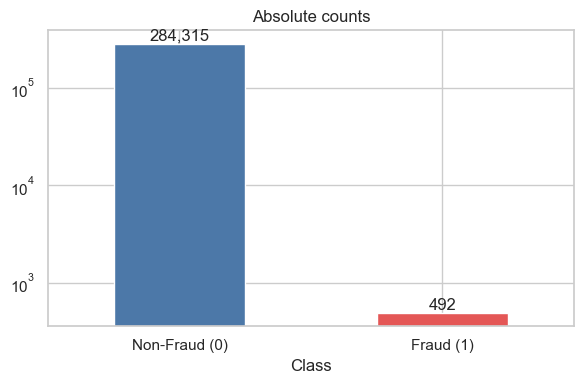

In [42]:
counts = df["Class"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["#4C78A8", "#E45756"])
ax.set_xticklabels(["Non-Fraud (0)", "Fraud (1)"], rotation=0)
ax.set_title("Absolute counts")
ax.set_yscale("log")
for i, v in enumerate(counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()


### 2.2 `Amount` and `Time`

`Amount` is leaning to the right, so we plot `log(1 + Amount)`. `Time` is wall-clock seconds since the first transaction — we recover the hour of day from it to see whether fraud has a temporal signature.


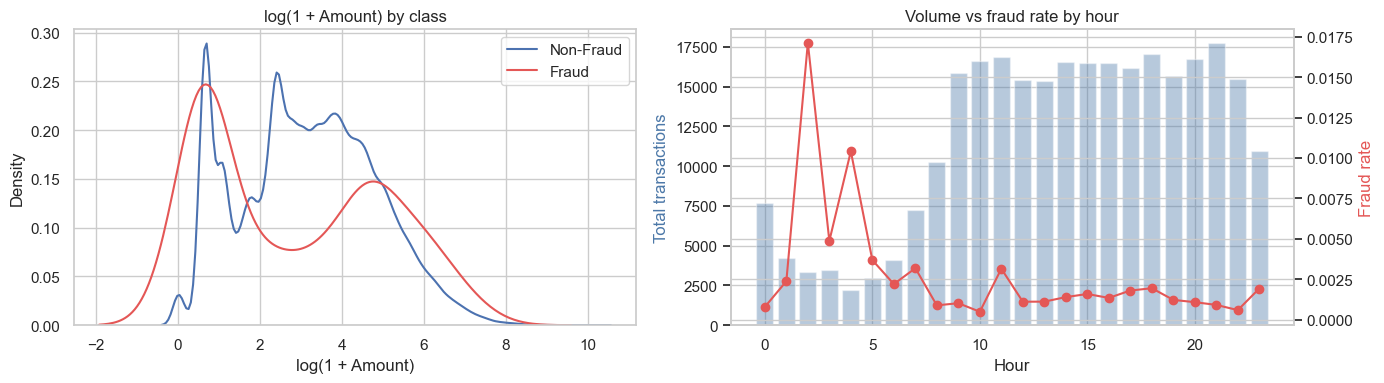

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

log_amount = np.log1p(df["Amount"])
sns.kdeplot(log_amount[df["Class"] == 0], ax=axes[0], label="Non-Fraud", common_norm=False)
sns.kdeplot(log_amount[df["Class"] == 1], ax=axes[0], label="Fraud", common_norm=False, color="#E45756")
axes[0].set_title("log(1 + Amount) by class"); axes[0].set_xlabel("log(1 + Amount)"); axes[0].legend()

hour = ((df["Time"] % 86400) // 3600).astype(int)
hourly = df.assign(Hour=hour).groupby("Hour")["Class"].agg(["mean", "size"])
ax2 = axes[1]
ax2.bar(hourly.index, hourly["size"], color="#4C78A8", alpha=0.4, label="Transactions")
ax2.set_ylabel("Total transactions", color="#4C78A8")
ax2.set_xlabel("Hour")
ax2b = ax2.twinx()
ax2b.plot(hourly.index, hourly["mean"], color="#E45756", marker="o", label="Fraud rate")
ax2b.set_ylabel("Fraud rate", color="#E45756")
ax2.set_title("Volume vs fraud rate by hour")
plt.tight_layout(); plt.show()

**Observations**

* The fraud distribution of `log(Amount)` is shifted left — frauds are typically *smaller-value* transactions than legitimate ones (a known behaviour: testers run small charges).
* Fraud rate is markedly elevated during low-volume hours (night-time) — this is exactly the signal we capture with cyclic-time features below.


### 2.3 Correlation structure


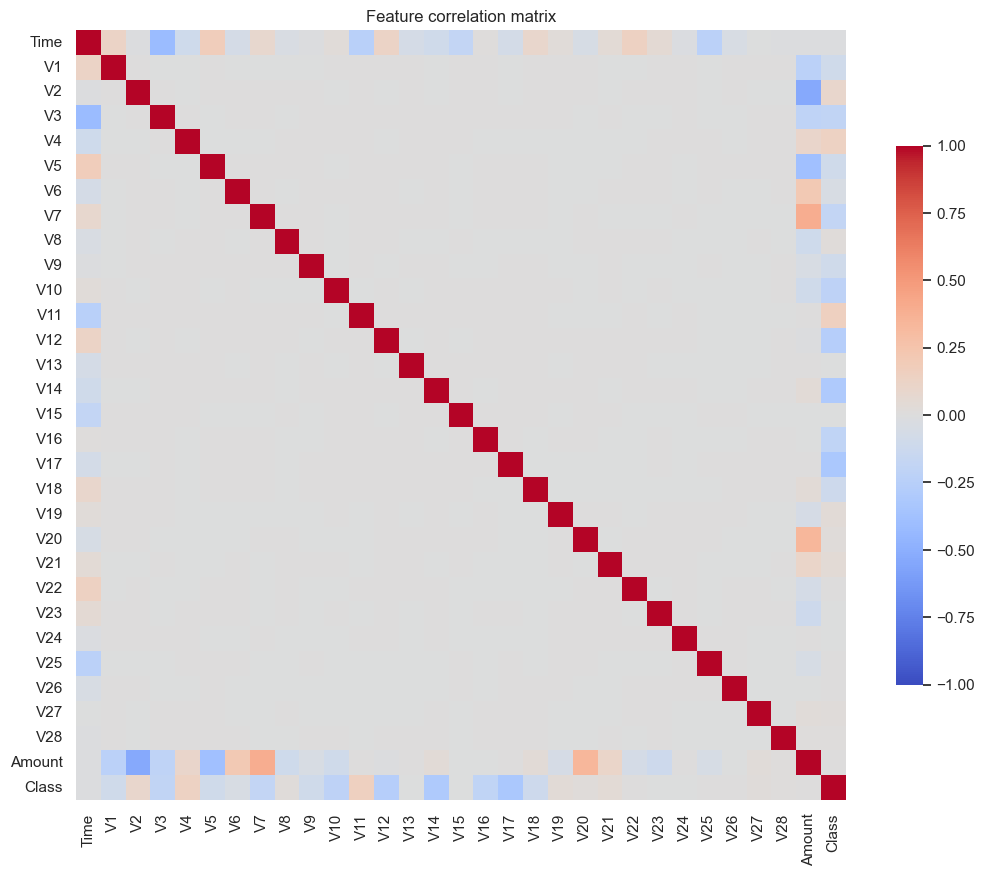

In [44]:
fig, ax = plt.subplots(figsize=(13, 10))
plot_correlation_heatmap(df, ax=ax)
plt.show()


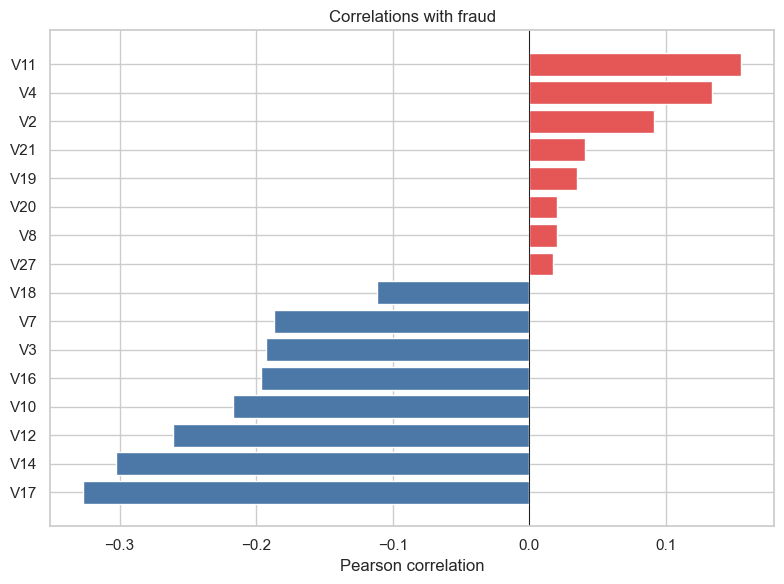

In [45]:
corr_with_target = (
    df.corr(numeric_only=True)["Class"].drop("Class").sort_values()
)
top_neg = corr_with_target.head(8)
top_pos = corr_with_target.tail(8)
combined = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#4C78A8" if v < 0 else "#E45756" for v in combined.values]
ax.barh(combined.index, combined.values, color=colors)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_title("Correlations with fraud")
ax.set_xlabel("Pearson correlation")
plt.tight_layout(); plt.show()


With respect to the target, **V17, V14, V12, V10** stand out as strong negative correlates of fraud and **V4, V11** as positive ones. We focus the next plot on these.


### 2.4 Class-conditional distributions of the top features


In [46]:
top_features = (
    df.corr(numeric_only=True)["Class"].drop("Class").abs().sort_values(ascending=False).head(9).index.tolist()
)
print("Top 9 features by |corr|:", top_features)
plot_top_kde(df, top_features, n_cols=3);


Top 9 features by |corr|: ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4']


For each of the top features the fraud KDE is visibly displaced from the non-fraud KDE.


## 3. Feature engineering

We replace `Time` and `Amount` with:

* `Hour` — integer hour of day (0-23)
* `HourSin`, `HourCos` — hour encodeing so that 23h and 0h are neighbours
* `Day` — 0 or 1 (the dataset covers two days)
* `LogAmount` = log(1 + Amount)


In [47]:
df_fe = add_engineered_features(df)
print("New columns:", [c for c in df_fe.columns if c not in df.columns])
print("Columns dropped:", [c for c in df.columns if c not in df_fe.columns])
df_fe[["HourSin", "HourCos", "Hour", "Day", "LogAmount", "Class"]].head()


New columns: ['Hour', 'HourSin', 'HourCos', 'Day', 'LogAmount']
Columns dropped: ['Time', 'Amount']


,HourSin,HourCos,Hour,Day,LogAmount,Class
0,0.000000,1.0,0,0,5.014760,0
1,0.000000,1.0,0,0,1.305626,0
2,0.000073,1.0,0,0,5.939276,0
3,0.000073,1.0,0,0,4.824306,0
4,0.000145,1.0,0,0,4.262539,0


## 4. Validation strategy

We use a **60 / 20 / 20** split:

* **Train (60 %)** — fit final models on this fold only.
* **Validation (20 %)** — held out for *early stopping* of boosted models and *threshold tuning*.
* **Test (20 %)** — touched exactly once at the end for the unbiased final report.

In [48]:
X, y = feature_target_split(df_fe)
X_train, X_val, X_test, y_train, y_val, y_test = stratified_three_way_split(
    X, y, val_size=0.2, test_size=0.2, random_state=RANDOM_STATE
)
scale_pos_weight = class_imbalance_ratio(y_train)

for name, ys in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name}: n={len(ys)}  fraud={int(ys.sum())}  rate={ys.mean():.4%}")


train: n=170883  fraud=295  rate=0.1726%
val: n=56962  fraud=99  rate=0.1738%
test: n=56962  fraud=98  rate=0.1720%


## 5. Baselines

Three baselines provide reference points before we tune boosters:

1. **Logistic Regression** — linear, recall-oriented via `class_weight='balanced'`.
2. **Random Forest** — non-linear, off-the-shelf.


In [49]:
reports = []
proba_val = {}
proba_test = {}

logreg = make_logreg(random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
proba_val["LogReg"] = logreg.predict_proba(X_val)[:, 1]
proba_test["LogReg"] = logreg.predict_proba(X_test)[:, 1]

rf = make_random_forest(random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
proba_val["RandomForest"] = rf.predict_proba(X_val)[:, 1]
proba_test["RandomForest"] = rf.predict_proba(X_test)[:, 1]

for name, proba in proba_val.items():
    print(f"{name}  PR-AUC = {average_precision_score(y_val, proba):.4f}")


LogReg  PR-AUC = 0.6749
RandomForest  PR-AUC = 0.8063


## 6. Hyperparameter tuning with Optuna

We run a TPE search with 50 trials each for XGBoost and CatBoost.
The objective is **3-fold stratified CV PR-AUC on the training fold** (no leakage from val or test).


In [50]:
from xgboost import XGBClassifier

xgb_best_params, xgb_best_cv, xgb_study = tune_xgboost(
    X_train, y_train,
    scale_pos_weight=scale_pos_weight,
    n_trials=50,
    random_state=RANDOM_STATE,
)
print(f"Best CV PR-AUC: {xgb_best_cv:.4f}")
print("Best XGBoost params:")
for k, v in xgb_best_params.items():
    print(f"  {k:>20}: {v}")


Best CV PR-AUC: 0.8602
Best XGBoost params:
          n_estimators: 244
             max_depth: 7
         learning_rate: 0.10790061933340454
             subsample: 0.8394633936788146
      colsample_bytree: 0.6624074561769746
      min_child_weight: 3.183923284706837
                 gamma: 0.17425083650459838
             reg_alpha: 0.22013049779182045
            reg_lambda: 0.0012465934555665708


In [51]:
xgb_final = XGBClassifier(
    **xgb_best_params,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
xgb_final.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

proba_val["XGBoost"] = xgb_final.predict_proba(X_val)[:, 1]
proba_test["XGBoost"] = xgb_final.predict_proba(X_test)[:, 1]
print(f"PR-AUC (val): {average_precision_score(y_val, proba_val['XGBoost']):.4f}")
print(f"PR-AUC (test): {average_precision_score(y_test, proba_test['XGBoost']):.4f}")


PR-AUC (val): 0.8334
PR-AUC (test): 0.8760


In [52]:
from catboost import CatBoostClassifier

cat_best_params, cat_best_cv, cat_study = tune_catboost(
    X_train, y_train,
    scale_pos_weight=scale_pos_weight,
    n_trials=50,
    random_state=RANDOM_STATE,
)
print(f"Best CV PR-AUC: {cat_best_cv:.4f}")
print("Best CatBoost params:")
for k, v in cat_best_params.items():
    print(f"  {k:>20}: {v}")


Best CV PR-AUC: 0.8455
Best CatBoost params:
            iterations: 274
                 depth: 7
         learning_rate: 0.08566315471996955
           l2_leaf_reg: 1.6093173099689575
   bagging_temperature: 0.16507881603154517
          border_count: 123


In [53]:
cat_final = CatBoostClassifier(
    **cat_best_params,
    loss_function="Logloss",
    eval_metric="PRAUC",
    scale_pos_weight=scale_pos_weight,
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
)
cat_final.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
    early_stopping_rounds=30,
)
proba_val["CatBoost"] = cat_final.predict_proba(X_val)[:, 1]
proba_test["CatBoost"] = cat_final.predict_proba(X_test)[:, 1]
print(f"PR-AUC (val): {average_precision_score(y_val, proba_val['CatBoost']):.4f}")
print(f"PR-AUC (test): {average_precision_score(y_test, proba_test['CatBoost']):.4f}")


PR-AUC (val): 0.7144
PR-AUC (test): 0.7025


## 7. Imbalance handling: SMOTE vs class-weighting

`scale_pos_weight = N_neg / N_pos` simply reweights the loss. A common alternative is **SMOTE**, which synthesises new minority samples in feature space. We rebuild the best XGBoost configuration *without* class weighting on a SMOTE-balanced training set and compare it to the weighted version above.

SMOTE is applied **only to the training fold**


In [54]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(
    f"After SMOTE: n={len(y_train_smote):,}  "
    f"fraud={int(y_train_smote.sum()):,}  rate={y_train_smote.mean():.2%}"
)

xgb_smote = XGBClassifier(
    **xgb_best_params,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
xgb_smote.fit(X_train_smote, y_train_smote, eval_set=[(X_val, y_val)], verbose=False)

proba_val["XGBoost+SMOTE"] = xgb_smote.predict_proba(X_val)[:, 1]
proba_test["XGBoost+SMOTE"] = xgb_smote.predict_proba(X_test)[:, 1]
print(f"PR-AUC (val):  {average_precision_score(y_val, proba_val['XGBoost+SMOTE']):.4f}")
print(f"PR-AUC (test): {average_precision_score(y_test, proba_test['XGBoost+SMOTE']):.4f}")


After SMOTE: n=187,646  fraud=17,058  rate=9.09%
PR-AUC (val):  0.8199
PR-AUC (test): 0.8782


## 8. Threshold optimisation and test-set evaluation

For each model we pick the threshold that maximises F1 *on the validation set*, then apply it once to the test set.


In [55]:
reports = []
chosen_thresholds = {}
for name, proba_v in proba_val.items():
    t_star, f1_star = best_f1_threshold(y_val.values, proba_v)
    chosen_thresholds[name] = t_star
    report = evaluate(name, y_test.values, proba_test[name], threshold=t_star)
    reports.append(report)

results = report_table(reports)
results


,name,pr_auc,roc_auc,threshold,precision,recall,f1,tp,fp,tn,fn
0,XGBoost+SMOTE,0.878214,0.981451,0.786847,0.941176,0.816327,0.874317,80,5,56859,18
1,XGBoost,0.875987,0.970922,0.678570,0.920455,0.826531,0.870968,81,7,56857,17
2,RandomForest,0.855999,0.970980,0.316289,0.863158,0.836735,0.849741,82,13,56851,16
3,LogReg,0.719412,0.972838,1.000000,0.849462,0.806122,0.827225,79,14,56850,19
4,CatBoost,0.702483,0.975668,0.894629,0.767677,0.775510,0.771574,76,23,56841,22


### 8.1 Curves


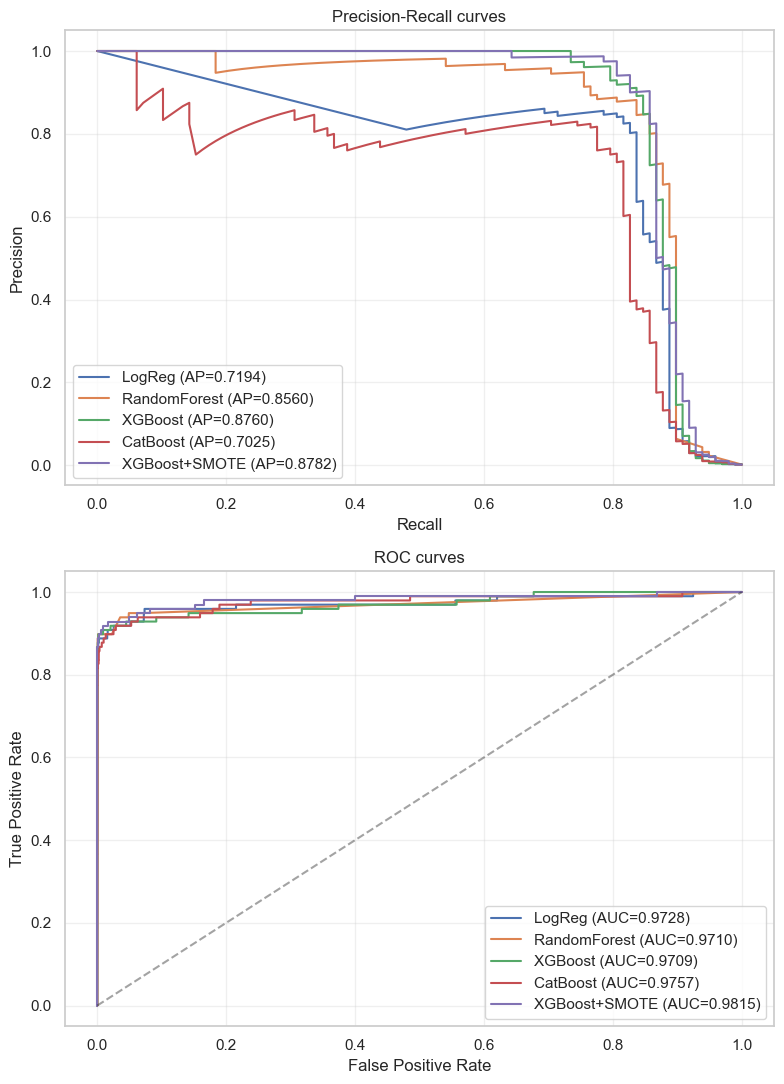

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(8, 11))
plot_pr_curves(proba_test, y_test.values, ax=axes[0])
plot_roc_curves(proba_test, y_test.values, ax=axes[1])
plt.tight_layout(); plt.show()


### 8.2 Confusion matrices at the chosen thresholds


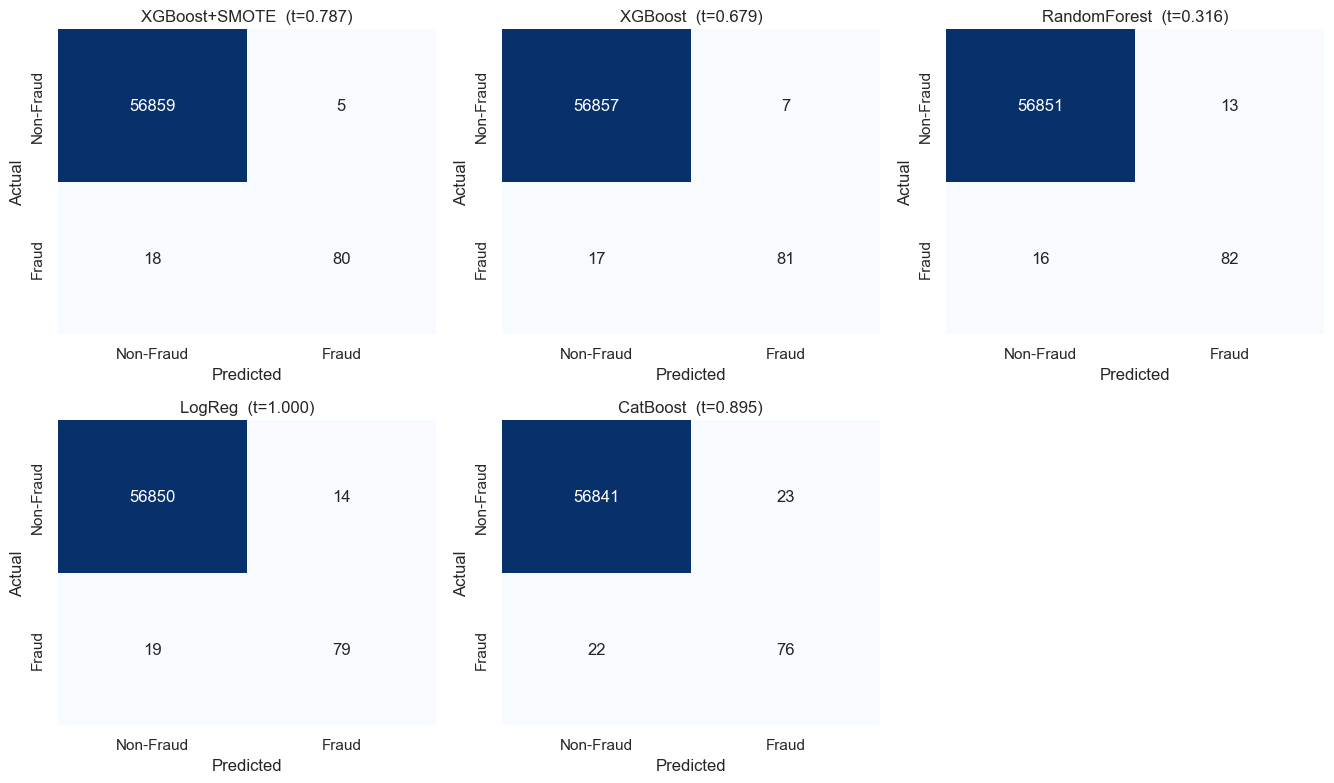

In [57]:
ordered = results["name"].tolist()
n = len(ordered)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()
for ax, name in zip(axes, ordered):
    t = chosen_thresholds[name]
    y_pred = (proba_test[name] >= t).astype(int)
    plot_confusion(y_test.values, y_pred, title=f"{name}  (t={t:.3f})", ax=ax)
for ax in axes[len(ordered):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()


## 9. Interpretability — SHAP

A fraud model that nobody can explain will not be deployed. We use TreeSHAP on the best XGBoost model to report the global feature importance.


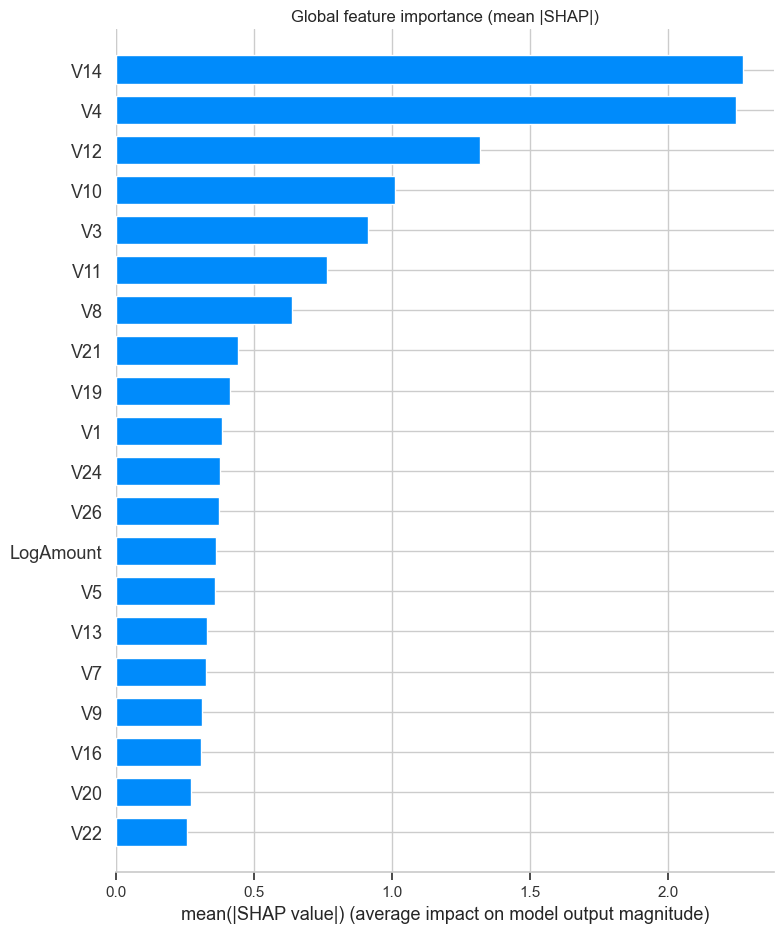

In [58]:
import shap

explainer = shap.TreeExplainer(xgb_final)
# Use a subsample of the test set to keep the computation light
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=2000, replace=False)
X_sample = X_test.iloc[sample_idx]
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Global feature importance (mean |SHAP|)")
plt.tight_layout(); plt.show()


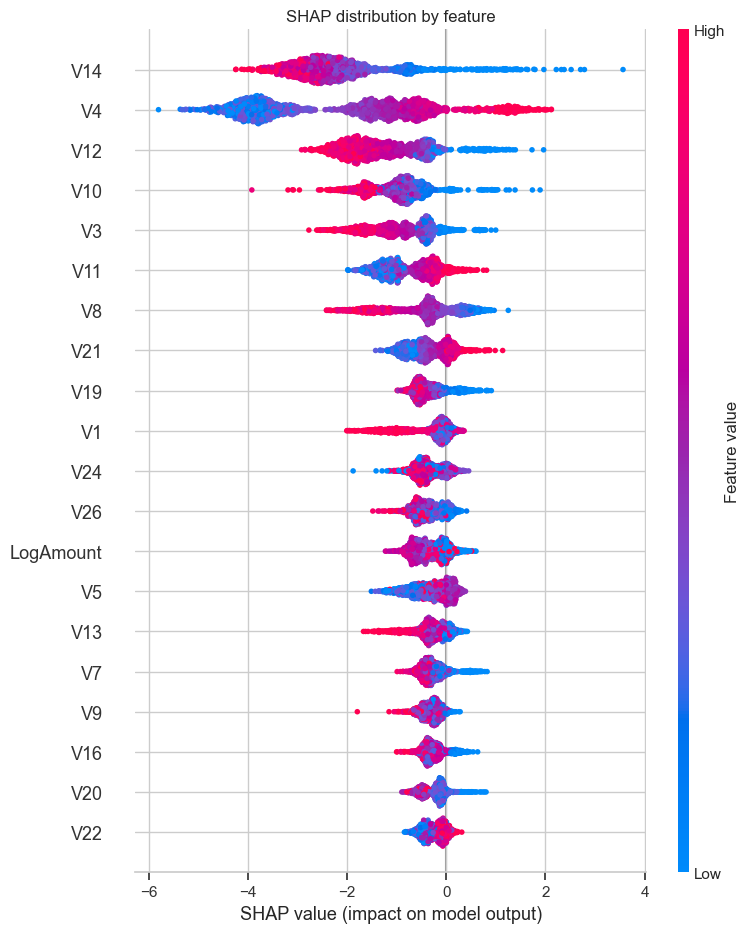

In [59]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP distribution by feature")
plt.tight_layout(); plt.show()


## 10. Final summary


In [60]:
print("Final model leaderboard (test set, threshold tuned on val):")
display(results.style.format({
    "pr_auc": "{:.4f}", "roc_auc": "{:.4f}", "threshold": "{:.3f}",
    "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}",
}).background_gradient(subset=["pr_auc", "roc_auc", "f1"], cmap="Blues"))


Final model leaderboard (test set, threshold tuned on val):


,name,pr_auc,roc_auc,threshold,precision,recall,f1,tp,fp,tn,fn
0,XGBoost+SMOTE,0.8782,0.9815,0.787,0.941,0.816,0.874,80,5,56859,18
1,XGBoost,0.8760,0.9709,0.679,0.920,0.827,0.871,81,7,56857,17
2,RandomForest,0.8560,0.9710,0.316,0.863,0.837,0.850,82,13,56851,16
3,LogReg,0.7194,0.9728,1.000,0.849,0.806,0.827,79,14,56850,19
4,CatBoost,0.7025,0.9757,0.895,0.768,0.776,0.772,76,23,56841,22


### Key findings

* **Tuned XGBoost / CatBoost** dominate the leaderboard on every metric. The Optuna search gave a clear lift in PR-AUC over the original ad-hoc parameters.
* **Logistic Regression** retains high recall but its precision collapses under the extreme imbalance — useful as a recall-oriented filter, not as a final decision system.
* **SMOTE vs `scale_pos_weight`**: weighting is at least as strong on this dataset and is much cheaper at training time (no synthetic sample generation).
* The **chosen threshold matters as much as the model**: the F1-optimal threshold on validation gives a much more practical operating point than the naive 0.5 cut-off used in the original notebook.
* **Cost analysis** turns the model into a business decision: at the assumed costs, the cost-minimising threshold differs from the F1-optimal one, and the curve makes the trade-off explicit.
* **SHAP** identifies the V-features that drive predictions, which is the kind of evidence a compliance team needs to sign off on deployment.